In [44]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
#data has no missing values, no need to drop na
df = pd.read_csv("data/updated_counts_avg_max_severity_dataset_main.csv")

In [46]:
df.describe()

,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence,violence_content_count,violence_avg_severity,...,mental_slurs_max_severity,religious_slurs_content_count,religious_slurs_avg_severity,religious_slurs_max_severity,racial_slurs_content_count,racial_slurs_avg_severity,racial_slurs_max_severity,sexual_content_content_count,sexual_content_avg_severity,sexual_content_max_severity
count,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,...,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000,7676.000000
mean,0.246287,0.569178,0.643822,0.044528,-8.411170,0.095515,120.425766,0.523931,49.056800,0.069809,...,0.574344,0.197368,0.046517,0.049076,4.135878,0.124159,0.238127,16.253387,0.095612,0.396555
std,0.289308,0.168391,0.231422,0.147939,3.857081,0.109332,29.788875,0.243595,33.844106,0.066366,...,0.365213,1.107510,0.170742,0.177715,6.628664,0.209709,0.363026,15.034866,0.121675,0.392110
min,0.000002,0.000000,0.000685,0.000000,-30.681000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.014675,0.450750,0.484000,0.000000,-10.778250,0.033600,96.391500,0.330000,24.000000,0.027095,...,0.189041,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.017064,0.054047
50%,0.105000,0.576500,0.676000,0.000017,-7.566500,0.047700,118.213500,0.524000,39.000000,0.050436,...,0.603975,0.000000,0.000000,0.000000,2.000000,0.010439,0.012194,11.000000,0.051181,0.189041
75%,0.420000,0.691000,0.836250,0.002262,-5.467250,0.102000,139.617500,0.720000,65.000000,0.091339,...,0.987151,0.000000,0.000000,0.000000,5.000000,0.174275,0.407421,22.000000,0.125041,0.895554
max,0.996000,0.986000,0.999000,0.992000,0.161000,0.956000,218.424000,0.985000,291.000000,0.994705,...,0.996763,62.000000,0.956862,0.956862,103.000000,0.997661,0.997661,183.000000,0.994731,0.996763


In [47]:
#The new data frame for 2000 rows of data
new_df = pd.read_csv("data/updated_counts_avg_max_severity_dataset.csv")

In [48]:
new_df.describe()

,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence,violence_content_count,violence_avg_severity,...,mental_slurs_max_severity,religious_slurs_content_count,religious_slurs_avg_severity,religious_slurs_max_severity,racial_slurs_content_count,racial_slurs_avg_severity,racial_slurs_max_severity,sexual_content_content_count,sexual_content_avg_severity,sexual_content_max_severity
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,...,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,0.162237,0.644787,0.685595,0.038015,-6.764677,0.110629,121.817967,0.506239,73.575712,0.071316,...,0.581995,0.198901,0.049763,0.052771,6.364818,0.153303,0.282747,24.427286,0.095520,0.417044
std,0.213674,0.148833,0.178653,0.138566,2.854083,0.105410,27.428235,0.223547,59.571230,0.065759,...,0.367308,0.918378,0.179752,0.188689,10.438048,0.241402,0.392201,22.415638,0.112993,0.397689
min,0.000007,0.153000,0.074700,0.000000,-21.877000,0.023000,62.175000,0.029400,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.012400,0.545000,0.566000,0.000000,-8.285000,0.040000,100.000000,0.335000,37.000000,0.027678,...,0.189041,0.000000,0.000000,0.000000,1.000000,0.000675,0.000675,10.000000,0.018528,0.120101
50%,0.067000,0.653000,0.709000,0.000006,-6.226000,0.062400,122.005000,0.508000,58.000000,0.050912,...,0.604499,0.000000,0.000000,0.000000,3.000000,0.012194,0.017341,18.000000,0.053846,0.189041
75%,0.227000,0.751000,0.825000,0.001060,-4.736000,0.139000,137.810000,0.678000,91.000000,0.095367,...,0.990219,0.000000,0.000000,0.000000,8.000000,0.235263,0.449542,31.000000,0.124037,0.988476
max,0.968000,0.975000,0.995000,0.929000,0.551000,0.817000,207.969000,0.975000,636.000000,0.622710,...,0.996763,18.000000,0.914395,0.936076,118.000000,0.997661,0.997661,210.000000,0.689212,0.996763


In [49]:
new_df.tail()

,lyrics,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence,explicit,...,mental_slurs_max_severity,religious_slurs_content_count,religious_slurs_avg_severity,religious_slurs_max_severity,racial_slurs_content_count,racial_slurs_avg_severity,racial_slurs_max_severity,sexual_content_content_count,sexual_content_avg_severity,sexual_content_max_severity
1996,"Spin around, 'round, 'round me Collide without a sound Caught up in your gravity I don't know how Run away, 'way, 'way from me A spirit only I can see I need you now 'Cause I don't know how I don't know what, what I was afraid of I was afraid of Monster take me somewhere Where I can see my breath in the air We walk in shadows Monster lead me home Where there is no place to hide Stranger on the other side We walk in shadows Monster lead me home Monster lead me home Now you surround, 'round, 'round me Didn't think I could be found Barefoot we tear through the streets Don't touch the ground A long way, way, way from comfort Keep our backs to the cold I need you now 'Cause I don't know how I don't know what, what I was afraid of I was afraid of Monster take me somewhere Where I can see my breath in the air We walk in shadows Monster lead me home Where there is no place to hide Stranger on the other side We walk in shadows Monster lead me home Monster lead me home NA Oh, Monster take me somewhere Where I can see my breath in the air We walk in shadows Monster lead me home Where there is no place to hide Stranger on the other side We walk in shadows Monster lead me home Monster lead me home",0.2080,0.595,0.824,0.00094,-6.692,0.0400,164.066,0.563,False,...,0.283120,0,0.000000,0.000000,15,0.228855,0.283120,18,0.003238,0.011791
1997,"No, it's... I can't, I can't really... I can't really just explain it It's... I don't know, it's... Uh, let me try Slow down I know you wanna understand So I'll explain the best I can What this pain feels like It's hard 'Cause even as I'm sitting here I would rather disappear Than face the world outside I'm floating in a fallen sky I'm okay, well, maybe not (Here it comes again) So I breathe, am I gonna drown? You'll be fine, I say it out loud I should let someone know Maybe when I'm better So I breathe, will it ever end? You'll be fine, I say it again I should let someone know That something doesn't feel right (Feel right) It's like I'm colorblind (It's like I'm colorblind) 'Cause everybody's world's in color Except for mine It sucks 'Cause everything's in black and white And I can't say I'm numb inside 'Cause that just sounds so dark It's hard 'Cause even as we're sitting here We're fighting off a constant fear But no one sees that part It's like I'm floating in a blacked out sky You think you're okay, but then you're not (Here it comes again) So I breathe, am I gonna drown? You'll be fine, I say it out loud I should let someone know Maybe when I'm better So I breathe, will it ever end? You'll be fine, I say it again I should let someone know That something doesn't feel right (Feel right) It's like I'm colorblind (It's like I'm colorblind) 'Cause everybody's world's in color Except for mine",0.1250,0.661,0.772,0.00015,-5.054,0.0362,146.002,0.186,False,...,0.685378,0,0.000000,0.000000,2,0.407421,0.407421,15,0.008533,0.039755
1998,"You were so blind to let me go You had it all but did not know No one you find will ever be Closer to all your dreams than me Believing the grass would be greener You told yourself I just don't need her now But I know you'll soon discover You're never satisfied with any other Someday, oh, someday The one you gave away Will be the only one you're wishing for Someday hey, hey Boy, you're going to pay 'Cause, baby, I'm the one who's keeping score You'll change your mind and call my name As soon as you find they're all the same And when you find yourself alone Don't come back crying, you should have known Believe me, I'm not pretending It's not hard to predict this ending now Because I know you'll so

In [50]:
#No missing values
df.isnull().sum()

lyrics                           0
acousticness                     0
danceability                     0
energy                           0
instrumentalness                 0
loudness                         0
speechiness                      0
tempo                            0
valence                          0
explicit                         0
violence_content_count           0
violence_avg_severity            0
violence_max_severity            0
drug_content_count               0
drug_avg_severity                0
drug_max_severity                0
hate_speech_content_count        0
hate_speech_avg_severity         0
hate_speech_max_severity         0
profanity_content_count          0
profanity_avg_severity           0
profanity_max_severity           0
mental_slurs_content_count       0
mental_slurs_avg_severity        0
mental_slurs_max_severity        0
religious_slurs_content_count    0
religious_slurs_avg_severity     0
religious_slurs_max_severity     0
racial_slurs_content

In [51]:
new_df.isnull().sum()

lyrics                           0
acousticness                     0
danceability                     0
energy                           0
instrumentalness                 0
loudness                         0
speechiness                      0
tempo                            0
valence                          0
explicit                         0
violence_content_count           0
violence_avg_severity            0
violence_max_severity            0
drug_content_count               0
drug_avg_severity                0
drug_max_severity                0
hate_speech_content_count        0
hate_speech_avg_severity         0
hate_speech_max_severity         0
profanity_content_count          0
profanity_avg_severity           0
profanity_max_severity           0
mental_slurs_content_count       0
mental_slurs_avg_severity        0
mental_slurs_max_severity        0
religious_slurs_content_count    0
religious_slurs_avg_severity     0
religious_slurs_max_severity     0
racial_slurs_content

In [52]:
# Load the updated dataset
#df = pd.read_csv("data/updated_counts_severity_dataset.csv")

# Ensure the target column has no missing values
#df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
#df["lyrics"].fillna("", inplace=True)

# Define feature sets
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]

#Max severity features
category_max_features = [
    "violence_max_severity", "drug_max_severity", "hate_speech_max_severity", 
    "profanity_max_severity", "mental_slurs_max_severity", "religious_slurs_max_severity", 
    "racial_slurs_max_severity", "sexual_content_max_severity"
]

'''
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]
'''

# Combine features for modeling
all_features = category_severity_features + category_max_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable
X_new_numerical = new_df[all_features]
y_new = new_df["explicit"]

In [53]:
# Convert lyrics to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
X_text = tfidf.fit_transform(df["lyrics"])

# Normalize numerical features
#imputer = SimpleImputer(strategy="mean")
scaler = MinMaxScaler()

#X_numerical_imputed = imputer.fit_transform(X_numerical)
X_numerical_scaled = scaler.fit_transform(X_numerical)

# Combine text and numerical features
X_combined = hstack([X_text, X_numerical_scaled])


In [54]:
#For new dataset, convert to tf-idf features
tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
X_text_new = tfidf.fit_transform(new_df["lyrics"])

# Normalize numerical features
#imputer_test = SimpleImputer(strategy="mean")

#X_new_numerical_imputed = imputer_test.fit_transform(X_test_numerical)
X_new_numerical_scaled = scaler.fit_transform(X_new_numerical)

# Combine text and numerical features
X_new_combined = hstack([X_text_new, X_new_numerical_scaled])


C:\Users\ziyue\AppData\Local\Temp\ipykernel_31352\4171791201.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")


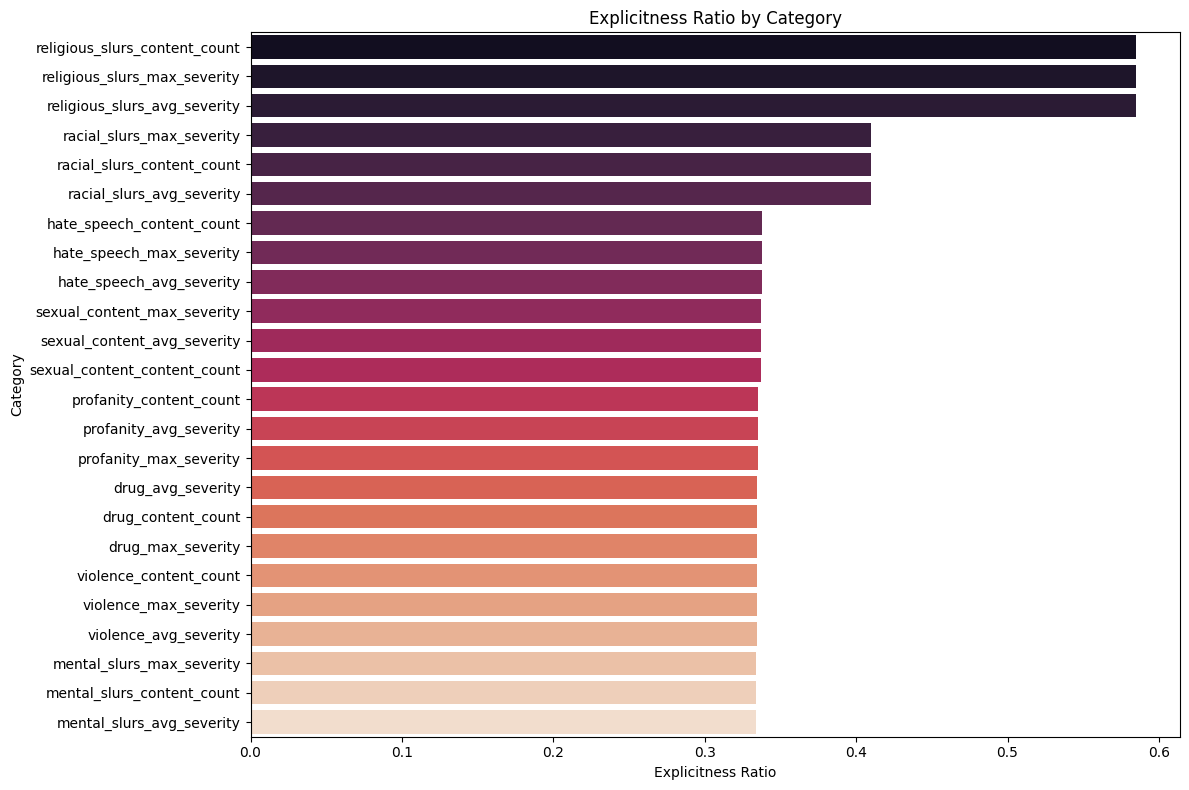

In [55]:
# Analyze explicitness ratios for count and severity features
category_ratios = {}
for category in category_count_features + category_severity_features + category_max_features:
    ratio = df[df[category] > 0]["explicit"].mean()
    category_ratios[category] = ratio

# Convert to DataFrame for visualization
category_ratios_df = pd.DataFrame({
    "Category": category_ratios.keys(),
    "Explicit Ratio": category_ratios.values()
}).sort_values(by="Explicit Ratio", ascending=False)

# Plot explicitness ratios
plt.figure(figsize=(12, 8))
sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")
plt.title("Explicitness Ratio by Category")
plt.xlabel("Explicitness Ratio")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


Naive Bayes Accuracy: 0.875
Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.92      0.91      1023
        True       0.83      0.79      0.81       513

    accuracy                           0.88      1536
   macro avg       0.86      0.85      0.86      1536
weighted avg       0.87      0.88      0.87      1536



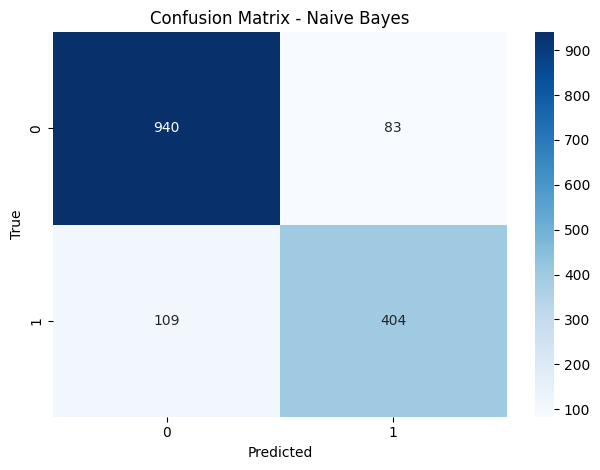

Naive Bayes class distribution: False    1049
True      487
Name: count, dtype: int64


In [56]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Evaluate Naive Bayes
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

# Plot confusion matrix
nb_cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("Naive Bayes class distribution:", pd.Series(y_pred_nb).value_counts())


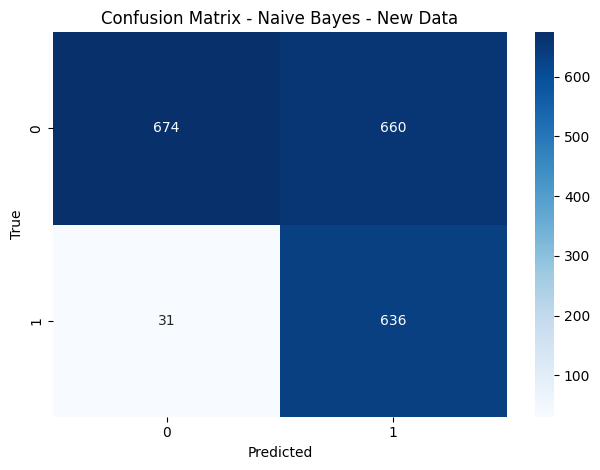

In [57]:
#analysis
y_pred_nb_new = nb_model.predict(X_new_combined)
#Draw a confusion Matrix of that
nb_cm_new = confusion_matrix(y_new, y_pred_nb_new)
sns.heatmap(nb_cm_new, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes - New Data")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [58]:
pd.set_option('display.max_colwidth', None)
#look at the sample songs predicted explicit but are not (i.e. False Positives)
new_vec_nb = (y_pred_nb_new == 1) & (y_new == 0)
indexlocs = []
for i in range(len(new_vec_nb)):
    if new_vec_nb[i] == True:
        indexlocs.append(i)
new_df_fn_nb = new_df.iloc[indexlocs, :].reset_index(drop=True)
new_df_fn_nb['lyrics'].sample(10, random_state=42)

629                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Analysis: For manual labeling, about 6/10 songs labeled are explicit. 

KNN Accuracy: 0.9016927083333334
Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.95      0.93      1023
        True       0.89      0.81      0.85       513

    accuracy                           0.90      1536
   macro avg       0.90      0.88      0.89      1536
weighted avg       0.90      0.90      0.90      1536



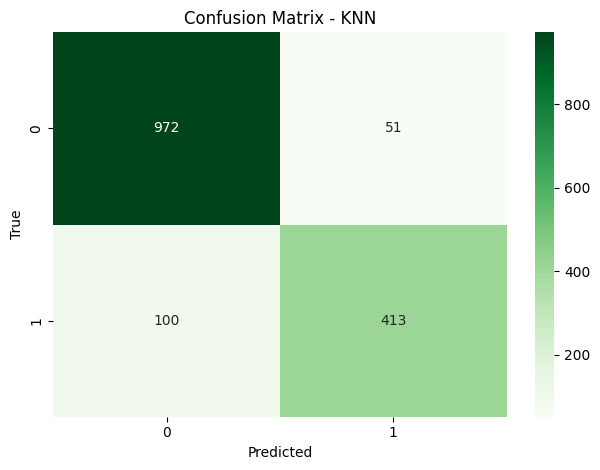

KNN class distribution: False    1072
True      464
Name: count, dtype: int64


In [59]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Evaluate KNN
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# Plot confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("KNN class distribution:", pd.Series(y_pred_knn).value_counts())


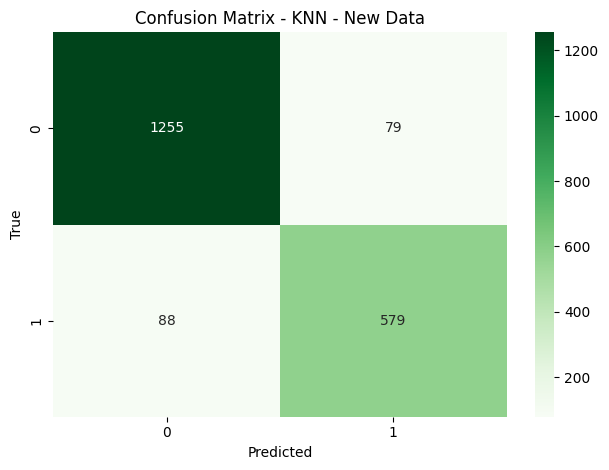

In [60]:
#analysis
y_pred_knn_new = knn_model.predict(X_new_combined)
#Draw a confusion Matrix of that
knn_cm_new = confusion_matrix(y_new, y_pred_knn_new)
sns.heatmap(knn_cm_new, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN - New Data")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [61]:
pd.set_option('display.max_colwidth', None)
#look at the sample songs predicted explicit but are not (i.e. False Positives)
new_vec_knn = (y_pred_knn_new == 1) & (y_new == 0)
indexlocs = []
for i in range(len(new_vec_knn)):
    if new_vec_knn[i] == True:
        indexlocs.append(i)
new_df_fn_knn = new_df.iloc[indexlocs, :].reset_index(drop=True)
new_df_fn_knn['lyrics'].sample(10, random_state=42)

30    You promised the world and I fell for it I put you first and you adored it Set fires to my forest And you let it burn Sang off-key in my chorus 'Cause it wasn't yours I saw the signs and I ignored it Rose-colored glasses all distorted Set fire to my purpose And I let it burn You got off on the hurtin' When it wasn't yours, yeah We'd always go into it blindly I needed to lose you to find me This dancing was killing me softly I needed to hate you to love me, yeah To love, love, yeah To love, love, yeah To love, yeah I needed to lose you to love me, yeah To love, love, yeah To love, love, yeah To love, yeah I needed to lose you to love me I gave my all and they all know it Then you tore me down and now it's showing In two months, you replaced us Like it was easy Made me think I deserved it In the thick of healing, yeah We'd always go into it blindly I needed to lose you to find me This dancing was killing me softly I needed to hate you to love me, yeah To love, love, yeah To love, l

Analysis: For manual labeling, about 8/10 songs labeled are explicit. 

C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3


C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


192/192 ━━━━━━━━━━━━━━━━━━━━ 47s 224ms/step - accuracy: 0.7872 - loss: 0.4821 - val_accuracy: 0.8828 - val_loss: 0.3217
Epoch 2/3
192/192 ━━━━━━━━━━━━━━━━━━━━ 52s 268ms/step - accuracy: 0.9030 - loss: 0.2655 - val_accuracy: 0.8822 - val_loss: 0.3140
Epoch 3/3
192/192 ━━━━━━━━━━━━━━━━━━━━ 56s 292ms/step - accuracy: 0.9281 - loss: 0.2120 - val_accuracy: 0.8822 - val_loss: 0.3129
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8950 - loss: 0.2881
LSTM Accuracy: 0.8822


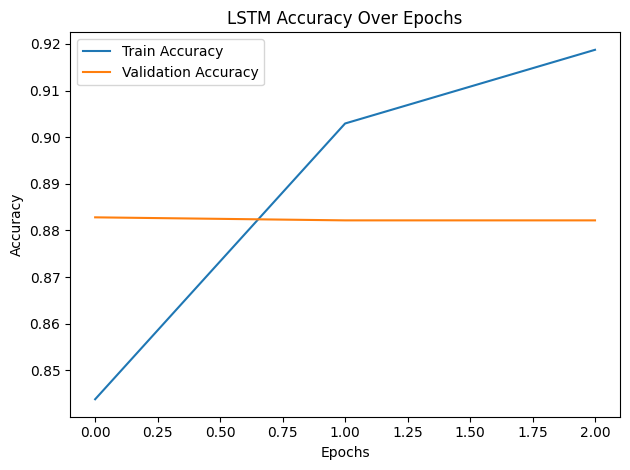

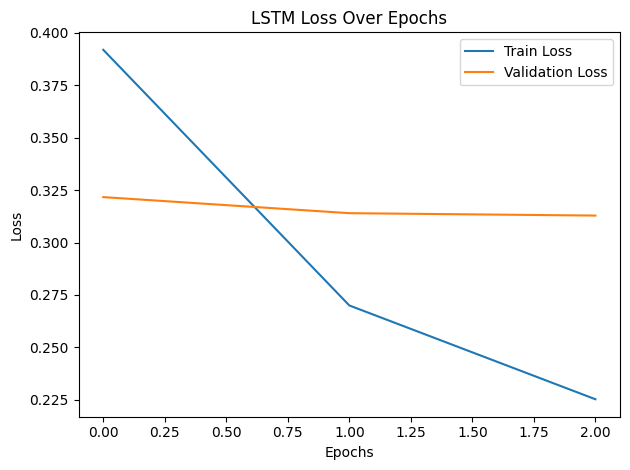

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step


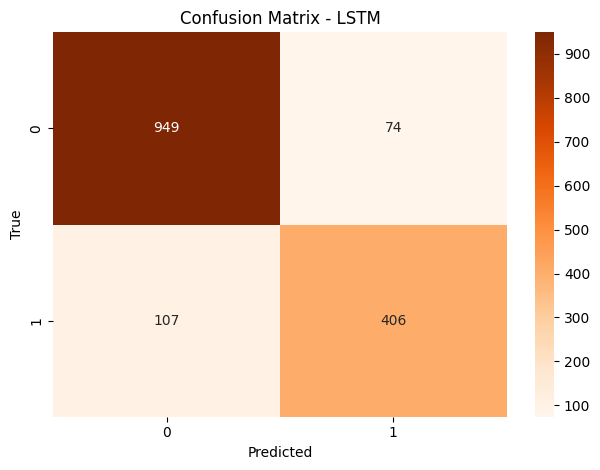

LSTM class distribution: 0    1056
1     480
Name: count, dtype: int64


In [62]:
# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["lyrics"])
X_text_seq = tokenizer.texts_to_sequences(df["lyrics"])
X_text_pad = pad_sequences(X_text_seq, maxlen=300)

# Train-test split
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text_pad, X_numerical_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define LSTM model
input_text = Input(shape=(300,))
input_num = Input(shape=(X_train_num.shape[1],))

text_embedding = Embedding(input_dim=5000, output_dim=64, input_length=300)(input_text)
text_lstm = LSTM(128)(text_embedding)

combined = Concatenate()([text_lstm, input_num])
dense = Dense(64, activation="relu")(combined)
dropout = Dropout(0.5)(dense)
output = Dense(1, activation="sigmoid")(dropout)

model = Model(inputs=[input_text, input_num], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train LSTM
history = model.fit(
    [X_train_text, X_train_num], y_train, epochs=3, batch_size=32, 
    validation_data=([X_test_text, X_test_num], y_test)
)

# Evaluate LSTM
loss, accuracy = model.evaluate([X_test_text, X_test_num], y_test)
print(f"LSTM Accuracy: {accuracy:.4f}")

# Plot training metrics
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# LSTM confusion matrix
lstm_pred = (model.predict([X_test_text, X_test_num]) > 0.5).astype(int)
lstm_cm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Class distribution
print("LSTM class distribution:", pd.Series(lstm_pred.flatten()).value_counts())


62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

C:\Users\ziyue\anaconda3\envs\6120\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step


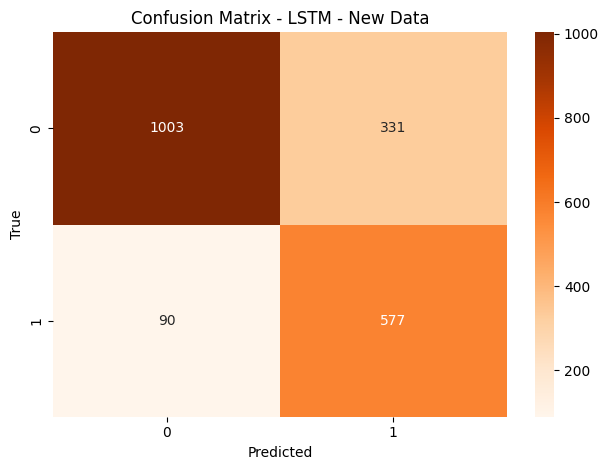

In [63]:
#Make predictions on new dataset
tokenizer.fit_on_texts(new_df["lyrics"])
X_text_seq_new = tokenizer.texts_to_sequences(new_df["lyrics"])
X_text_pad_new = pad_sequences(X_text_seq_new, maxlen=300)
y_pred_lstm = model.predict([X_text_pad_new, X_new_numerical_scaled])
y_pred_lstm_new = (y_pred_lstm > 0.5).astype(int).flatten().tolist()

lstm_cm = confusion_matrix(y_new, y_pred_lstm_new)
sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - LSTM - New Data")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [64]:
pd.set_option('display.max_colwidth', None)
#look at the sample songs predicted explicit but are not (i.e. False Positives)
indexlocs_lstm = [i for i in range(len(y_pred_lstm_new)) if y_pred_lstm_new[i] == 1 and y_new[i] == 0]
new_df_fn_lstm = new_df.iloc[indexlocs_lstm, :].reset_index(drop=True)
new_df_fn_lstm['lyrics'].sample(10, random_state=42)

25     (Would you do for me) Sweetheart (Would you do for me) I'm talking to you and no one else I just want you to know... (Would you do for me) ...that I'll do for you If you do for me I will do for you Well, excuse me, let me let you know the time On, how I feel and what's on my mind It's you that I want to be in my life And if it's possible, you will be my wife I lead you in the right direction, of course Never play you out, so there's no loss I'll be your love daddy, just wait and see That me and you, we were meant to be If you do for me (I'll do) I will do for you (For you) If you do for me (I'll do...) I will do for you (...I'll do for you) If you do for me (I'll do) I will do for you (For you...) If you do for me I will do for you I wanna treat ya like a queen Cook and clean Get your bubble bath ready so I can rub you with Noxzem' And watch how gentle I'll be when I rub your back And after that there's dinner and cognac A little romance for the quiet storm And a lotta lovin' fo

About 4/10 songs are considered explicit from manual labeling

In [65]:
#data has no missing values, no need to drop na
df = pd.read_csv("data/updated_counts_avg_max_severity_dataset_main.csv")
# Load the updated dataset
new_df = pd.read_csv("data/updated_counts_avg_max_severity_dataset.csv")
#df = pd.read_csv("data/updated_counts_severity_dataset.csv")

# Ensure the target column has no missing values
#df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
#df["lyrics"].fillna("", inplace=True)

# Define feature sets
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]

#Max severity features
category_max_features = [
    "violence_max_severity", "drug_max_severity", "hate_speech_max_severity", 
    "profanity_max_severity", "mental_slurs_max_severity", "religious_slurs_max_severity", 
    "racial_slurs_max_severity", "sexual_content_max_severity"
]

'''
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]'''

# Combine features for modeling
all_features = category_severity_features + category_max_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable
X_new_numerical = new_df[all_features]
y_new = new_df["explicit"]

In [77]:
# Convert lyrics to TF-IDF features
#tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
#X_text = tfidf.fit_transform(df["lyrics"])

# Normalize numerical features
#imputer = SimpleImputer(strategy="mean")
#scaler = MinMaxScaler()

X_numerical_imputed = X_numerical.reset_index(drop=True).to_numpy()
#X_numerical_scaled = scaler.fit_transform(X_numerical_imputed)

# Combine text and numerical features
#X_combined = hstack([X_text, X_numerical_scaled])


In [78]:
import torch
from transformers import BertModel
from transformers import BertTokenizer

text = list(df['lyrics'])
#X_numerical_scaled, y = torch.tensor(X_numerical_scaled), torch.tensor(y)
y = torch.tensor(y)
text_b_train, text_b_test, X_train_b_num, X_test_b_num, y_b_train, y_b_test = train_test_split(text, X_numerical_imputed, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\ziyue\AppData\Local\Temp\ipykernel_31352\533369087.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y)


In [79]:
class SongExplicitnessModel(torch.nn.Module):
    def __init__(self, transformer_model_name='bert-base-uncased', num_numerical_features=len(X_train_b_num[0])):
        super(SongExplicitnessModel, self).__init__()
        self.transformer = BertModel.from_pretrained(transformer_model_name)
        self.fc_text = torch.nn.Linear(self.transformer.config.hidden_size, 256)  # Text-to-hidden layer
        self.fc_numerical = torch.nn.Linear(len(X_train_b_num[0]), 64)  # Numerical-to-hidden layer
        self.fc_combined = torch.nn.Linear(256 + 64, 1)  # Combined layer
        self.sigmoid = torch.nn.Sigmoid()  # For binary classification (explicit or not)

    def forward(self, input_ids, attention_mask, numerical_features):
        # Pass text through the BERT model
        text_output = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        text_embedding = text_output.last_hidden_state.mean(dim=1)  # Mean pooling to get a fixed-size embedding

        #print("Text Embedding Shape:", text_embedding.shape)
        text_embedding = self.fc_text(text_embedding)

        
        # Process numerical features
        numerical_embedding = self.fc_numerical(numerical_features)
        #print("Numerical Embedding Shape:", numerical_embedding.shape)

        # Combine the text and numerical features
        combined = torch.cat((text_embedding, numerical_embedding), dim=1)
        combined_output = self.fc_combined(combined)
        # print("Combined Shape:", combined.shape)
        
        # Output layer
        output = self.sigmoid(combined_output)
        # During forward pass
        return output

In [80]:
# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example sentences
texts = list(text_b_train)

# Tokenize the inputs and generate the attention_mask
'''encoded_inputs = tokenizer(
    texts,                         # Input texts
    padding=True,                  # Pad shorter sequences to match the longest
    truncation=True,               # Truncate longer sequences to max_length
    max_length=128,                 # Set a max length for padding/truncation
    return_tensors="pt"            # Return PyTorch tensors
)

# The resulting dictionary contains:
input_ids = encoded_inputs['input_ids']          # Token IDs for the sentences
attention_mask = encoded_inputs['attention_mask']  # Attention mask (1s and 0s)

print("Input IDs:\n", input_ids)
print("Attention Mask:\n", attention_mask)'''

'encoded_inputs = tokenizer(\n    texts,                         # Input texts\n    padding=True,                  # Pad shorter sequences to match the longest\n    truncation=True,               # Truncate longer sequences to max_length\n    max_length=128,                 # Set a max length for padding/truncation\n    return_tensors="pt"            # Return PyTorch tensors\n)\n\n# The resulting dictionary contains:\ninput_ids = encoded_inputs[\'input_ids\']          # Token IDs for the sentences\nattention_mask = encoded_inputs[\'attention_mask\']  # Attention mask (1s and 0s)\n\nprint("Input IDs:\n", input_ids)\nprint("Attention Mask:\n", attention_mask)'

In [81]:
from torch.utils.data import Dataset, DataLoader

class SongDataset(Dataset):
    def __init__(self, texts, numerical_features, labels, tokenizer, max_length=128):
        self.texts = texts
        self.numerical_features = numerical_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        numerical_feature = self.numerical_features[idx]
        label = self.labels[idx]

        tokenized = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return (
            tokenized['input_ids'].squeeze(0),
            tokenized['attention_mask'].squeeze(0),
            torch.tensor(numerical_feature, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

dataset = SongDataset(text_b_train, X_train_b_num, y_b_train, tokenizer)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
test_dataset = SongDataset(text_b_test, X_test_b_num, y_b_test, tokenizer)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [82]:
from torch.optim import Adam

model = SongExplicitnessModel()
criterion = torch.nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
optimizer = Adam(model.parameters(), lr=0.6e-4)

device = "cpu"
model.to(device)

SongExplicitnessModel(
  (transformer): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [ ]:
num_epochs = 3
losses = []
epochs = []
accuracies = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0
    for input_ids, attention_mask, numerical_features, labels in dataloader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        numerical_features = numerical_features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, numerical_features)
        outputs= outputs.squeeze(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        predictions = torch.round(outputs)  # Example for binary classification
        #print(predictions, labels)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)

    epoch_accuracy = correct_predictions / total_predictions
    accuracies.append(epoch_accuracy)
    print(f"Epoch {epoch + 1}/{num_epochs}, Accuracy: {epoch_accuracy}, Loss: {epoch_loss / len(dataloader):.4f}")
    epochs.append(epoch+1)
    losses.append(epoch_loss / len(dataloader))
    fpath = "transformer_model_no_audio_checkpoint_{f}.pth".format(f=epoch)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        }, fpath)
torch.save(model, 'transformer_model_no_audio.pth')

C:\Users\ziyue\AppData\Local\Temp\ipykernel_31352\1980449341.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(label, dtype=torch.float32)


In [ ]:
fig = plt.figure()
plt.title("Epochs vs Loss", fontsize=16)
plt.plot(epochs, losses)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()
fig.savefig("epochs_vs_loss.jpg")

In [ ]:
model = torch.load("transformer_model.pth")
model.eval()

In [ ]:
#model.eval()
#model.train()
epoch_loss = 0
correct_predictions = 0
total_predictions = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for input_ids, attention_mask, numerical_features, labels in test_dataloader:
        #passing to the model
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        numerical_features = numerical_features.to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask, numerical_features)
        outputs= outputs.squeeze(-1)

        #compute loss
        loss = criterion(outputs, labels)
        epoch_loss += loss.item()

        predictions = torch.round(outputs)  # Example for binary classification
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        #print(predictions, labels)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)
epoch_accuracy = correct_predictions / total_predictions
bert_cm = confusion_matrix(all_labels, all_preds)
print(f"Accuracy: {epoch_accuracy}, Loss: {epoch_loss / len(test_dataloader):.4f}")
print("Classification Report:\n", classification_report(all_labels, all_preds))
sns.heatmap(bert_cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Bert Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()    